## Digit Recognizer

This project classifies handwritten digit images (0-9) from the classic MNIST dataset. It is the standard "hello world" of image classification, and a good first Kaggle image competition.

## Approach
1. Load the data and view a few example digits as images
2. Scale pixel values and train a baseline classifier
3. Evaluate accuracy on a validation split
4. Generate predictions and create the submission file
5. Submit to Kaggle and record the score

In [1]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle API token and press Enter: ")

!pip install -q -U kaggle
!kaggle competitions download -c digit-recognizer
!unzip -oq digit-recognizer.zip

Paste your Kaggle API token and press Enter: ··········
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.0 MB/s eta 0:00:00
100% 15.3M/15.3M [00:00<00:00, 62.3MB/s]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


In [5]:
train.sample(1)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
41412,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
test.sample(1)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
536,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print(train.shape, test.shape)

(42000, 785) (28000, 784)


In [8]:
train["label"].value_counts().sort_index()

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


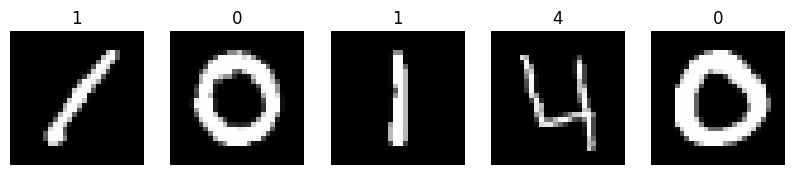

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(train.iloc[i]["label"])
    ax.axis("off")
plt.show()

In [10]:
x = train.drop(columns=["label"]) / 255.0
y = train["label"]

x_test = test / 255.0

In [12]:
print(x.shape, y.shape, x_test.shape)

(42000, 784) (42000,) (28000, 784)


In [13]:
x.values.min(), x.values.max()

(np.float64(0.0), np.float64(1.0))

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

pred = model.predict(x_val)
print("Validation accuracy:", round(accuracy_score(y_val, pred), 4))

Validation accuracy: 0.9663


In [15]:
model.fit(x, y)

pred_test = model.predict(x_test)

pd.DataFrame({"ImageId": range(1, len(pred_test) + 1), "Label": pred_test}).to_csv("submission.csv", index=False)

In [16]:
!kaggle competitions submit -c digit-recognizer -f submission.csv -m "RandomForest baseline"

100% 208k/208k [00:00<00:00, 341kB/s]
4 submissions remaining today.
Successfully submitted to Digit Recognizer

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier(max_iter=150, random_state=42)
model.fit(x, y)

import pickle, os
pickle.dump(model, open("digit_model.pkl", "wb"))
print("size MB:", round(os.path.getsize("digit_model.pkl") / 1e6, 2))

size MB: 5.41
